# This Section Concerns all mentioned Datasets with Random Forest

# Imports

/home/t1yeh/.conda/envs/cogs118a/bin/python


In [22]:
# Standard library
import os

# Data handling
import numpy as np
import pandas as pd
from scipy import sparse

# GPU libraries (optional for cuML models)
import cupy as cp
from cuml.ensemble import RandomForestClassifier

# ML utilities
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve
)

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt




def load_split(data, split, base_path="../data/splits/"):
    """
    Loads X_train, X_test, y_train, y_test for a given dataset + split.
    Automatically detects whether features are stored as sparse (.npz)
    or dense (.csv).

    Example:
        X_train, X_test, y_train, y_test = load_split("cup98", "7030")
    """

    path = os.path.join(base_path, split)

    # ---- Load X_train ----
    npz_path = os.path.join(path, f"X_train_{data}.npz")
    csv_path = os.path.join(path, f"X_train_{data}.csv")

    if os.path.exists(npz_path):
        X_train = sparse.load_npz(npz_path)
    else:
        X_train = pd.read_csv(csv_path)

    # ---- Load X_test ----
    npz_path = os.path.join(path, f"X_test_{data}.npz")
    csv_path = os.path.join(path, f"X_test_{data}.csv")

    if os.path.exists(npz_path):
        X_test = sparse.load_npz(npz_path)
    else:
        X_test = pd.read_csv(csv_path)

    # ---- Load labels ----
    y_train = pd.read_csv(os.path.join(path, f"y_train_{data}.csv"))
    y_test  = pd.read_csv(os.path.join(path, f"y_test_{data}.csv"))

    # Convert DataFrames → Series
    y_train = y_train.iloc[:, 0]
    y_test  = y_test.iloc[:, 0]

    return X_train, X_test, y_train, y_test



def load_all_by_split(datasets, base_path="../data/splits/"):
    split_types = ["7030", "3070", "5050"]
    result = {split: {} for split in split_types}

    for split in split_types:
        print(f"\n=== Loading {split} splits ===")
        for data in datasets:
            print(f"  -> Loading {data}")
            X_train, X_test, y_train, y_test = load_split(data, split, base_path)
            result[split][data] = {
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test
            }

    return result

# Note on Replicating Breiman–Cutler Random Forest mtry Settings in cuML

The original Breiman–Cutler Random Forest algorithm allows specifying the **exact number of features (`mtry`)** to consider at each split. The experiment we aim to replicate uses: https://www.cs.cornell.edu/~caruana/ctp/ct.papers/caruana.icml06.pdf(Page 2)


However, **cuML’s RandomForestClassifier does not support integer `max_features` values**. Instead, cuML expects:

- A **float** in the range (0, 1], representing the *fraction of total input features*, or  
- One of the preset strings: `"auto"`, `"sqrt"`, `"log2"`

To approximate the classical Breiman–Cutler behavior on GPU, we convert each integer `mtry` into the corresponding fraction of the full feature dimension:
cuML_max_features = mtry / num_features

This scaling preserves the **intended constraint on the number of candidate split features**, allowing us to run an RF experiment that matches the methodology as closely as possible within cuML’s API.

For each dataset, we will train **8 GPU-accelerated Random Forests**, each using:

- `n_estimators = 1024`
- `max_features = mtry / num_features`
- `mtry ∈ {1, 2, 4, 6, 8, 12, 16, 20}`

This provides the closest functional replication of the Breiman–Cutler experimental setting while benefiting from cuML’s GPU performance.




In [23]:


def Tree_Training_Testing(data, mtry_values=[1, 2, 4, 6, 8, 12, 16, 20]):
    """
    Trains 8 GPU RF models with integer mtry approximated as fractions.
    
    Parameters:
        data: dict with "X_train", "y_train", "X_test", "y_test"
        mtry_values: list of integer feature counts (Breiman–Cutler settings)
    
    Returns:
        results: dict mapping mtry → accuracy
    """
    
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]

    num_features = X_train.shape[1]
    results = {}

    print(f"Total features: {num_features}")

    for mtry in mtry_values:
        # convert integer mtry → fraction for cuML
        frac = mtry / num_features
        frac = min(max(frac, 1.0 / num_features), 1.0)  # safety clamp

        print(f"\nTraining RF with mtry={mtry} → max_features={frac:.4f}")

        rf = RandomForestClassifier(
            n_estimators=1024,
            max_depth=50,
            max_features=frac,
            n_streams=8
        )

        rf.fit(X_train, y_train)

        # Predict on GPU and convert to CPU
        preds_cpu = cp.asnumpy(rf.predict(X_test))
        y_test_cpu = cp.asnumpy(y_test)

        acc = accuracy_score(y_test_cpu, preds_cpu)
        results[mtry] = acc

        print(f"Accuracy (mtry={mtry}): {acc:.4f}")

    return results

def evaluate_model(preds_gpu, y_test, title="Model Evaluation"):
    # Convert GPU → CPU
    preds = cp.asnumpy(preds_gpu)
    y_test_cpu = cp.asnumpy(y_test)

    # ======== Accuracy ========
    acc = accuracy_score(y_test_cpu, preds)
    print(f"\n=== {title} ===")
    print(f"Accuracy: {acc:.4f}")

    # ======== Precision / Recall / F1 ========
    print("\nClassification Report:")
    print(classification_report(y_test_cpu, preds))

    # ======== Confusion Matrix ========
    cm = confusion_matrix(y_test_cpu, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======== ROC Curve (Binary only) ========
    if len(cp.unique(y_test)) == 2:  
        try:
            # AUC
            auc = roc_auc_score(y_test_cpu, preds)
            print(f"AUC: {auc:.4f}")

            # ROC curve
            fpr, tpr, _ = roc_curve(y_test_cpu, preds)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
            plt.plot([0,1], [0,1], 'k--')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curve: {title}")
            plt.legend()
            plt.show()
        except Exception as e:
            print("Could not compute ROC:", e)
    else:
        print("\nROC/AUC skipped (not binary classification).")

In [24]:
datasets = ["wine", "cup98", "customer"]

all_splits = load_all_by_split(datasets)



=== Loading 7030 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 3070 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer

=== Loading 5050 splits ===
  -> Loading wine
  -> Loading cup98
  -> Loading customer


# 30 70 Split

## Wine Data

Total features: 12

Training RF with mtry=1 → max_features=0.0833


/home/t1yeh/.conda/envs/cogs118a/lib/python3.10/site-packages/cuml/internals/api_decorators.py:188: UserWarning: To use pickling first train using float32 data to fit the estimator
  ret = func(*args, **kwargs)


Accuracy (mtry=1): 0.9912

Training RF with mtry=2 → max_features=0.1667


/home/t1yeh/.conda/envs/cogs118a/lib/python3.10/site-packages/cuml/internals/api_decorators.py:188: UserWarning: To use pickling first train using float32 data to fit the estimator
  ret = func(*args, **kwargs)


Accuracy (mtry=2): 0.9927

Training RF with mtry=4 → max_features=0.3333


...

Accuracy (mtry=16): 0.9870

Training RF with mtry=20 → max_features=1.0000


/home/t1yeh/.conda/envs/cogs118a/lib/python3.10/site-packages/cuml/internals/api_decorators.py:188: UserWarning: To use pickling first train using float32 data to fit the estimator
  ret = func(*args, **kwargs)


Accuracy (mtry=20): 0.9870
Best mtry: 2


/home/t1yeh/.conda/envs/cogs118a/lib/python3.10/site-packages/cuml/internals/api_decorators.py:188: UserWarning: To use pickling first train using float32 data to fit the estimator
  ret = func(*args, **kwargs)



=== Wine (best mtry=2) ===
Accuracy: 0.9927

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3429
           1       0.99      0.98      0.99      1120

    accuracy                           0.99      4549
   macro avg       0.99      0.99      0.99      4549
weighted avg       0.99      0.99      0.99      4549



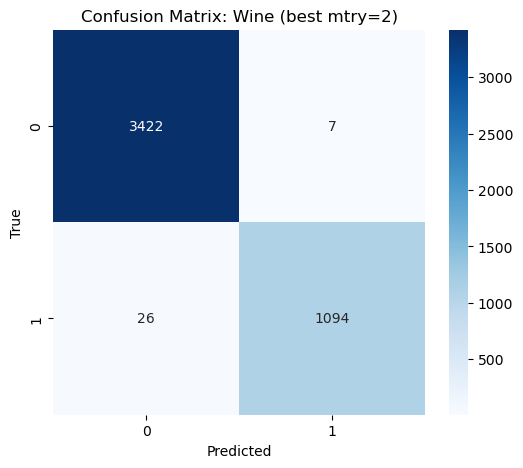

AUC: 0.9874


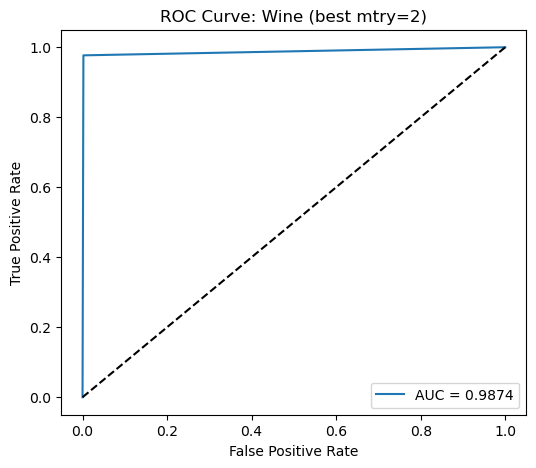

In [29]:
wine_3070 = all_splits["3070"]["wine"]
results = Tree_Training_Testing(wine_3070)

best_mtry = max(results, key=results.get)
print("Best mtry:", best_mtry)

# Retrain using best mtry
best_rf = RandomForestClassifier(
    n_estimators=1024,
    max_depth=50,
    max_features=best_mtry / wine_3070["X_train"].shape[1],
    n_streams=8
)

best_rf.fit(wine_3070["X_train"], wine_3070["y_train"])
preds_gpu = best_rf.predict(wine_3070["X_test"])

# Now evaluate fully
evaluate_model(preds_gpu, wine_3070["y_test"], title=f"Wine (best mtry={best_mtry})")



In [6]:
cup98_3070    = all_splits["3070"]["cup98"]
customer_3070 = all_splits["3070"]["customer"]

# 70 30 Split

In [7]:
wine_7030     = all_splits["7030"]["wine"]
cup98_7030    = all_splits["7030"]["cup98"]
customer_7030 = all_splits["7030"]["customer"]



# 50 50 Split

In [8]:
wine_5050     = all_splits["5050"]["wine"]
cup98_5050    = all_splits["5050"]["cup98"]
customer_5050 = all_splits["5050"]["customer"]


